# Ablation Study: Visual Feature Effects on Probe Ideology Scores

32 synthetic portraits (male, white, blonde, American flag) are cumulatively edited
to remove one trait at a time. The probe ideology score is measured at each step.

**Ablation chain:**  
`step0 (Base)` → `step1 (−Flag)` → `step2 (−Blonde)` → `step3 (−White)` → `step4 (−Male)`

Models: Qwen3-VL & Gemma4, headwise_linear probe.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy import stats

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
STEP_ORDER = ["step0_base", "step1_no_flag", "step2_dark_hair", "step3_nonwhite", "step4_female"]
STEP_LABELS = ["Base\n(M,W,B,F)", "−Flag", "−Blonde", "−White", "−Male"]
STEP_SHORT = ["Base", "−Flag", "−Blonde", "−White", "−Male"]
TRAIT_NAMES = ["Remove Flag", "Blonde→Dark", "White→Non-white", "Male→Female"]

def load_ablation_stats(model_base_name):
    path = Path(f"results/{model_base_name}/prompt_token_stats_combined_ideology_headwise_linear.csv")
    df = pd.read_csv(path)
    df["person_id"] = df["record_id"].str.extract(r"ablation_(person_\d+)_")
    df["person_num"] = df["person_id"].str.extract(r"person_(\d+)").astype(int)
    df["step"] = df["record_id"].str.extract(r"ablation_person_\d+_(\w+)")
    return df[["record_id", "person_id", "person_num", "step", "image_mean", "image_std"]].dropna(subset="step")

def pivot_scores(df):
    piv = df.pivot(index="person_num", columns="step", values="image_mean")
    return piv[STEP_ORDER]

qwen_df = load_ablation_stats("qwen3-vl-8b-instruct")
gemma_df = load_ablation_stats("gemma-4-31b-it")
qwen_piv = pivot_scores(qwen_df)
gemma_piv = pivot_scores(gemma_df)

print(f"Qwen3-VL: {len(qwen_df)} records, {qwen_df['person_id'].nunique()} persons")
print(f"Gemma4:   {len(gemma_df)} records, {gemma_df['person_id'].nunique()} persons")
print(f"Steps: {sorted(qwen_df['step'].unique())}")
qwen_piv.head()

Qwen3-VL: 160 records, 32 persons
Gemma4:   160 records, 32 persons
Steps: ['step0_base', 'step1_no_flag', 'step2_dark_hair', 'step3_nonwhite', 'step4_female']


step,step0_base,step1_no_flag,step2_dark_hair,step3_nonwhite,step4_female
person_num,,,,,
1,0.388211,0.130879,0.086638,0.089480,-0.142182
2,0.307400,0.113582,0.086484,0.075900,-0.093009
3,0.341528,0.043158,-0.023499,-0.042016,-0.132002
4,0.305853,0.080826,0.058090,0.045236,-0.072350
5,0.352900,0.093319,-0.021482,-0.057751,0.031303


## Table 1 — Per-Step Mean Score & Cumulative Shift

In [3]:
def sig(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    elif p < 0.10: return "."
    return ""

def build_step_table(piv, model_name):
    means = piv.mean(); sems = piv.sem(); rows = []; prev = None
    for i in range(5):
        m, se = means[STEP_ORDER[i]], sems[STEP_ORDER[i]]
        d = m - prev if prev is not None else None
        rows.append({"Step": STEP_SHORT[i], "Mean": f"{m:.4f}", "±SE": f"{se:.4f}",
                     "Δ from prev": f"{d:+.4f}" if d is not None else "—"})
        prev = m
    return pd.DataFrame(rows)

print("=".center(60,"=")); print("QWEN3-VL".center(60)); print("=".center(60,"="))
display(build_step_table(qwen_piv, "Qwen3-VL"))
print("=".center(60,"=")); print("GEMMA4".center(60)); print("=".center(60,"="))
display(build_step_table(gemma_piv, "Gemma4"))

                          QWEN3-VL                          


,Step,Mean,±SE,Δ from prev
0,Base,0.3982,0.0208,—
1,−Flag,0.1250,0.0218,-0.2732
2,−Blonde,0.0524,0.0250,-0.0727
3,−White,0.0436,0.0249,-0.0088
4,−Male,-0.1078,0.0204,-0.1513


                           GEMMA4                           


,Step,Mean,±SE,Δ from prev
0,Base,0.4860,0.0133,—
1,−Flag,0.4216,0.0186,-0.0644
2,−Blonde,0.3721,0.0203,-0.0494
3,−White,0.3827,0.0193,+0.0105
4,−Male,0.1597,0.0148,-0.2230


## Table 2 — Paired Δ per Trait Removal

In [4]:
def paired_stats(piv):
    rows = []
    for i in range(4):
        diffs = piv[STEP_ORDER[i+1]] - piv[STEP_ORDER[i]]
        m, se, sd = diffs.mean(), diffs.sem(), diffs.std()
        t, p = stats.ttest_1samp(diffs, 0)
        ci = f"[{m-1.96*se:+.4f}, {m+1.96*se:+.4f}]"
        d = m/sd if sd > 0 else 0
        rows.append({"Ablation": TRAIT_NAMES[i], "Mean Δ": f"{m:+.4f}{sig(p)}",
                     "95% CI": ci, "t": f"{t:.2f}", "p": f"{p:.4f}", "d": f"{d:.3f}"})
    return pd.DataFrame(rows)

print("QWEN3-VL"); display(paired_stats(qwen_piv))
print("GEMMA4"); display(paired_stats(gemma_piv))

QWEN3-VL


,Ablation,Mean Δ,95% CI,t,p,d
0,Remove Flag,-0.2732***,"[-0.2983, -0.2481]",-21.35,0.0000,-3.774
1,Blonde→Dark,-0.0727***,"[-0.0870, -0.0583]",-9.94,0.0000,-1.757
2,White→Non-white,-0.0088.,"[-0.0182, +0.0006]",-1.83,0.0772,-0.323
3,Male→Female,-0.1513***,"[-0.1817, -0.1210]",-9.78,0.0000,-1.729


GEMMA4


,Ablation,Mean Δ,95% CI,t,p,d
0,Remove Flag,-0.0644***,"[-0.0842, -0.0445]",-6.36,0.0000,-1.124
1,Blonde→Dark,-0.0494***,"[-0.0652, -0.0337]",-6.14,0.0000,-1.085
2,White→Non-white,+0.0105,"[-0.0041, +0.0251]",1.41,0.1672,0.250
3,Male→Female,-0.2230***,"[-0.2462, -0.1998]",-18.85,0.0000,-3.332


## Figure 1 — Cumulative Score Shift (Waterfall)

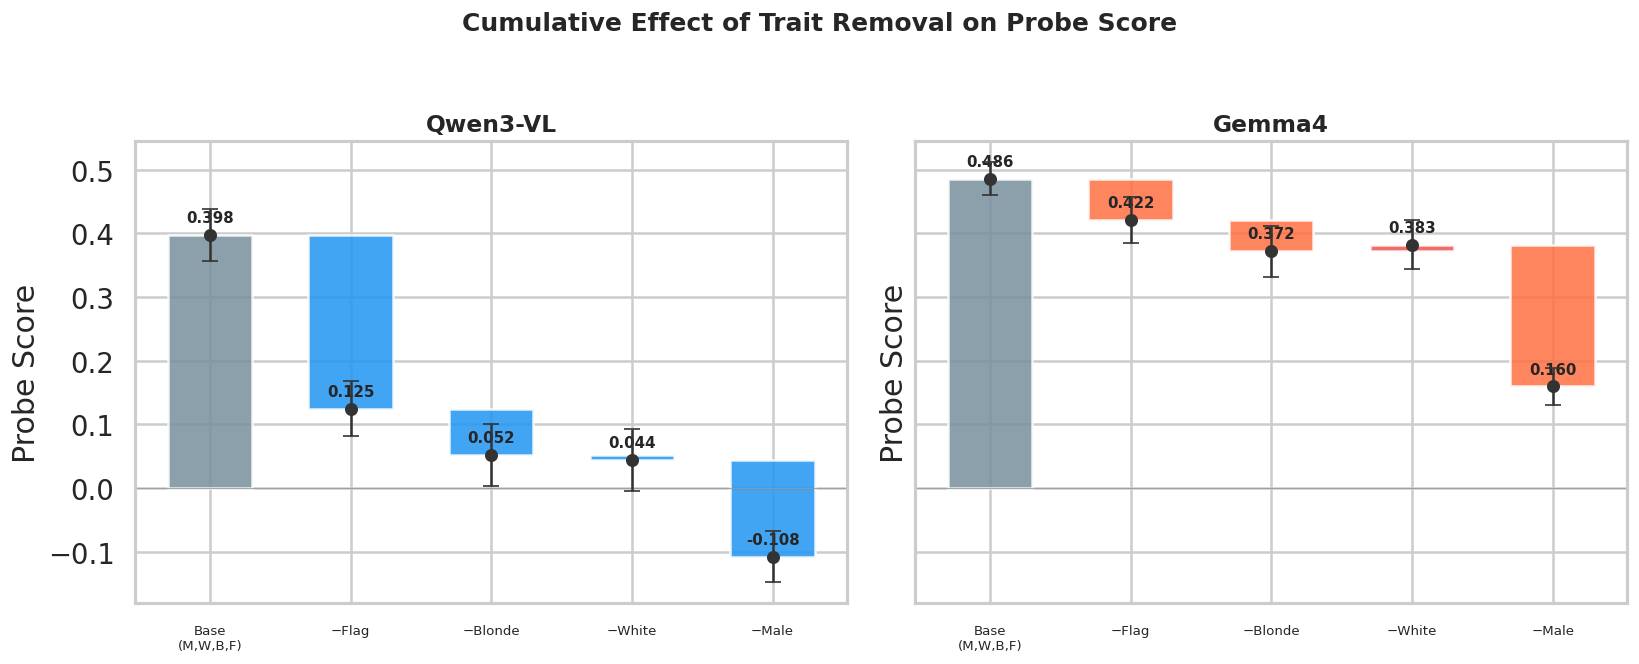

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, piv, title, color in [(axes[0], qwen_piv, "Qwen3-VL", "#2196F3"), (axes[1], gemma_piv, "Gemma4", "#FF7043")]:
    means = piv.mean().values; sems = piv.sem().values; x = np.arange(5)
    for i in range(5):
        bottom = 0 if i == 0 else means[i-1]
        height = means[i] if i == 0 else means[i] - means[i-1]
        bar_c = "#78909C" if i == 0 else (color if height < 0 else "#EF5350")
        ax.bar(i, height, bottom=bottom, color=bar_c, alpha=0.85, edgecolor="white", linewidth=1.5, width=0.6)
    ax.errorbar(x, means, yerr=1.96*sems, fmt="none", ecolor="#333", capsize=5, linewidth=1.5, zorder=5)
    ax.scatter(x, means, color="#333", s=40, zorder=6)
    for xi, m in zip(x, means):
        ax.text(xi, m+0.02, f"{m:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(STEP_LABELS, fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=14); ax.set_ylabel("Probe Score")
    ax.axhline(0, color="#999", linewidth=0.5, linestyle="-")
fig.suptitle("Cumulative Effect of Trait Removal on Probe Score", fontweight="bold", fontsize=15, y=1.02)
fig.tight_layout(); plt.show()

## Figure 2 — Per-Person Score Trajectories

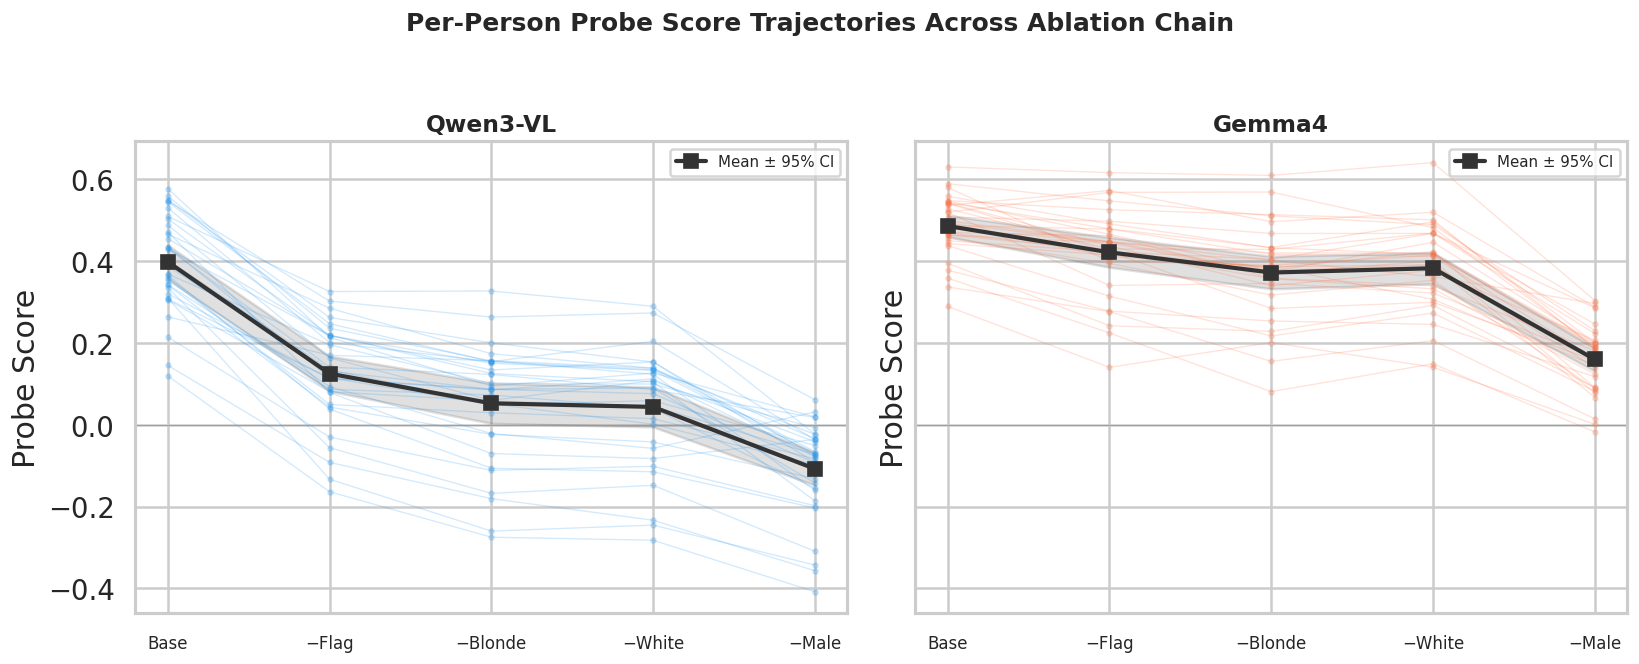

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, piv, title, color in [(axes[0], qwen_piv, "Qwen3-VL", "#2196F3"), (axes[1], gemma_piv, "Gemma4", "#FF7043")]:
    x = np.arange(5)
    for pn in piv.index:
        ax.plot(x, piv.loc[pn].values, color=color, alpha=0.2, linewidth=0.8, marker="o", markersize=3)
    ax.plot(x, piv.mean().values, color="#333", linewidth=2.5, marker="s", markersize=8, label="Mean ± 95% CI", zorder=10)
    ax.fill_between(x, piv.mean().values - 1.96*piv.sem().values, piv.mean().values + 1.96*piv.sem().values, color="#333", alpha=0.15)
    ax.set_xticks(x); ax.set_xticklabels(STEP_SHORT, fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=14); ax.set_ylabel("Probe Score"); ax.legend(fontsize=9)
    ax.axhline(0, color="#999", linewidth=0.5, linestyle="-")
fig.suptitle("Per-Person Probe Score Trajectories Across Ablation Chain", fontweight="bold", fontsize=15, y=1.02)
fig.tight_layout(); plt.show()

## Figure 3 — Per-Trait Effect Sizes (Paired Δ)

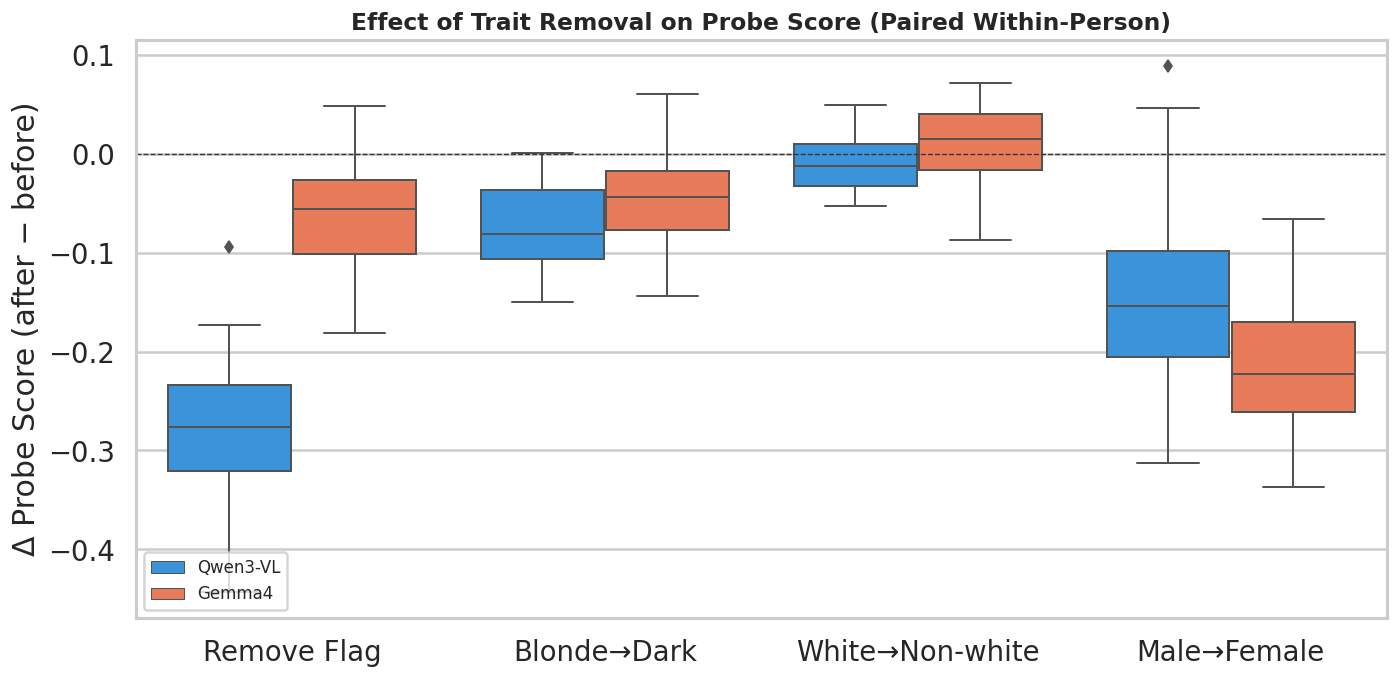

In [7]:
deltas = []
for model_name, piv in [("Qwen3-VL", qwen_piv), ("Gemma4", gemma_piv)]:
    for i in range(4):
        diff = piv[STEP_ORDER[i+1]] - piv[STEP_ORDER[i]]
        for pn, d in diff.items():
            deltas.append({"model": model_name, "trait": TRAIT_NAMES[i], "delta": d})
all_deltas = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=all_deltas, x="trait", y="delta", hue="model",
            palette={"Qwen3-VL": "#2196F3", "Gemma4": "#FF7043"}, linewidth=1.2, ax=ax)
ax.axhline(0, color="#333", linewidth=0.8, linestyle="--")
ax.set_ylabel("Δ Probe Score (after − before)"); ax.set_xlabel("")
ax.set_title("Effect of Trait Removal on Probe Score (Paired Within-Person)", fontweight="bold", fontsize=14)
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout(); plt.show()

## Figure 4 — Observational Regression vs. Ablation Experiment

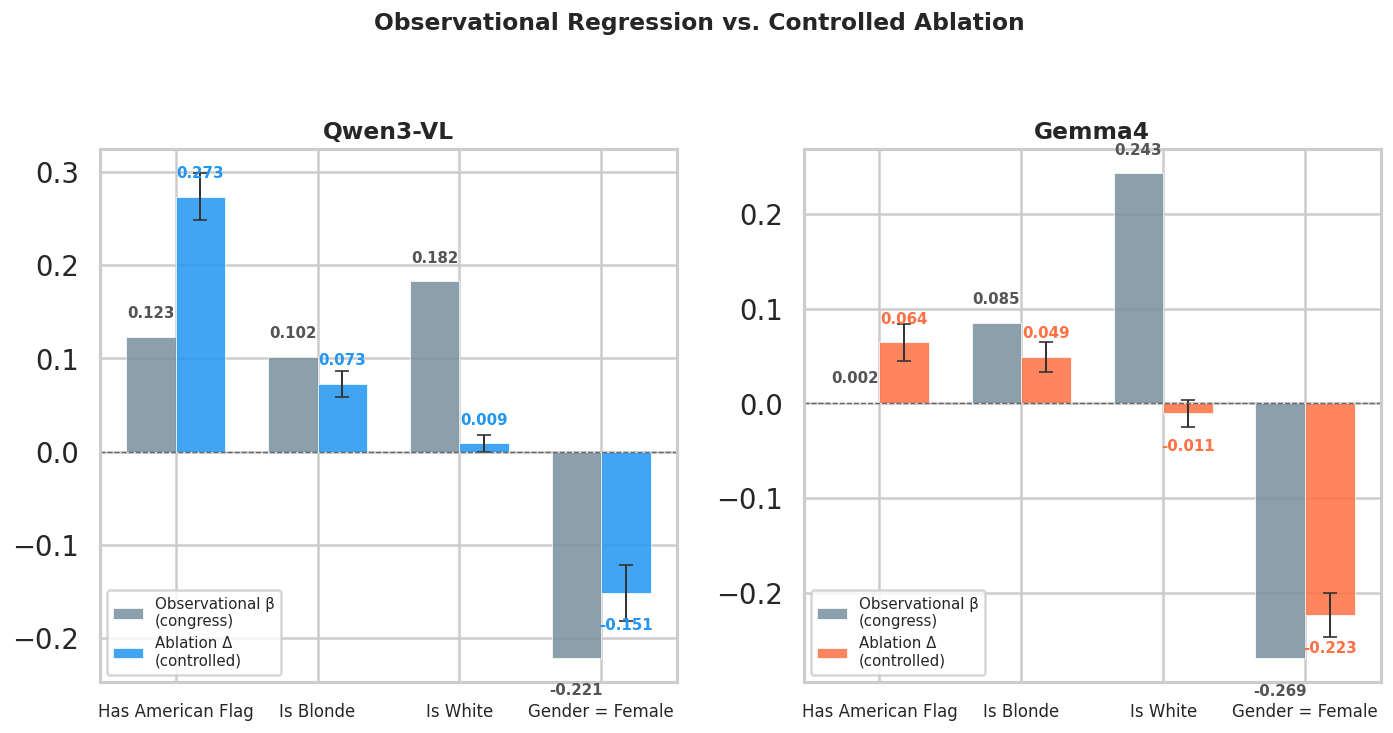

In [8]:
OBS_QWEN = {"Has American Flag": 0.1230, "Is Blonde": 0.1016, "Is White": 0.1825, "Gender = Female": -0.2211}
OBS_GEMMA = {"Has American Flag": 0.0015, "Is Blonde": 0.0854, "Is White": 0.2428, "Gender = Female": -0.2687}

def abl_effects(piv):
    return {
        "Has American Flag": piv[STEP_ORDER[0]] - piv[STEP_ORDER[1]],
        "Is Blonde": piv[STEP_ORDER[1]] - piv[STEP_ORDER[2]],
        "Is White": piv[STEP_ORDER[2]] - piv[STEP_ORDER[3]],
        "Gender = Female": piv[STEP_ORDER[4]] - piv[STEP_ORDER[3]],
    }

ae_q = {k: v.mean() for k, v in abl_effects(qwen_piv).items()}
ae_g = {k: v.mean() for k, v in abl_effects(gemma_piv).items()}
ae_q_se = {k: v.sem() for k, v in abl_effects(qwen_piv).items()}
ae_g_se = {k: v.sem() for k, v in abl_effects(gemma_piv).items()}

trait_order = ["Has American Flag", "Is Blonde", "Is White", "Gender = Female"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
x = np.arange(4); width = 0.35
for ax, model, obs, ae, ae_se, color in [
    (axes[0], "Qwen3-VL", OBS_QWEN, ae_q, ae_q_se, "#2196F3"),
    (axes[1], "Gemma4", OBS_GEMMA, ae_g, ae_g_se, "#FF7043")]:
    ov = [obs[t] for t in trait_order]; av = [ae[t] for t in trait_order]; ases = [ae_se[t] for t in trait_order]
    b1 = ax.bar(x - width/2, ov, width, label="Observational β\n(congress)", color="#78909C", alpha=0.85, edgecolor="white", linewidth=0.5)
    b2 = ax.bar(x + width/2, av, width, label="Ablation Δ\n(controlled)", color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.errorbar(x + width/2, av, yerr=1.96*np.array(ases), fmt="none", ecolor="#333", capsize=4, linewidth=1.2)
    for bar, val in zip(b1, ov):
        off = 0.02 if val >= 0 else -0.04
        ax.text(bar.get_x()+bar.get_width()/2, val+off, f"{val:.3f}", ha="center", fontsize=9, fontweight="bold", color="#555")
    for bar, val in zip(b2, av):
        off = 0.02 if val >= 0 else -0.04
        ax.text(bar.get_x()+bar.get_width()/2, val+off, f"{val:.3f}", ha="center", fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(x); ax.set_xticklabels(trait_order, fontsize=10)
    ax.axhline(0, color="#666", linewidth=0.8, linestyle="--")
    ax.set_title(model, fontweight="bold", fontsize=14); ax.legend(fontsize=9, loc="lower left")
fig.suptitle("Observational Regression vs. Controlled Ablation", fontweight="bold", fontsize=14, y=1.03)
fig.tight_layout(); plt.show()

## Figure 5 — Score Distributions by Step

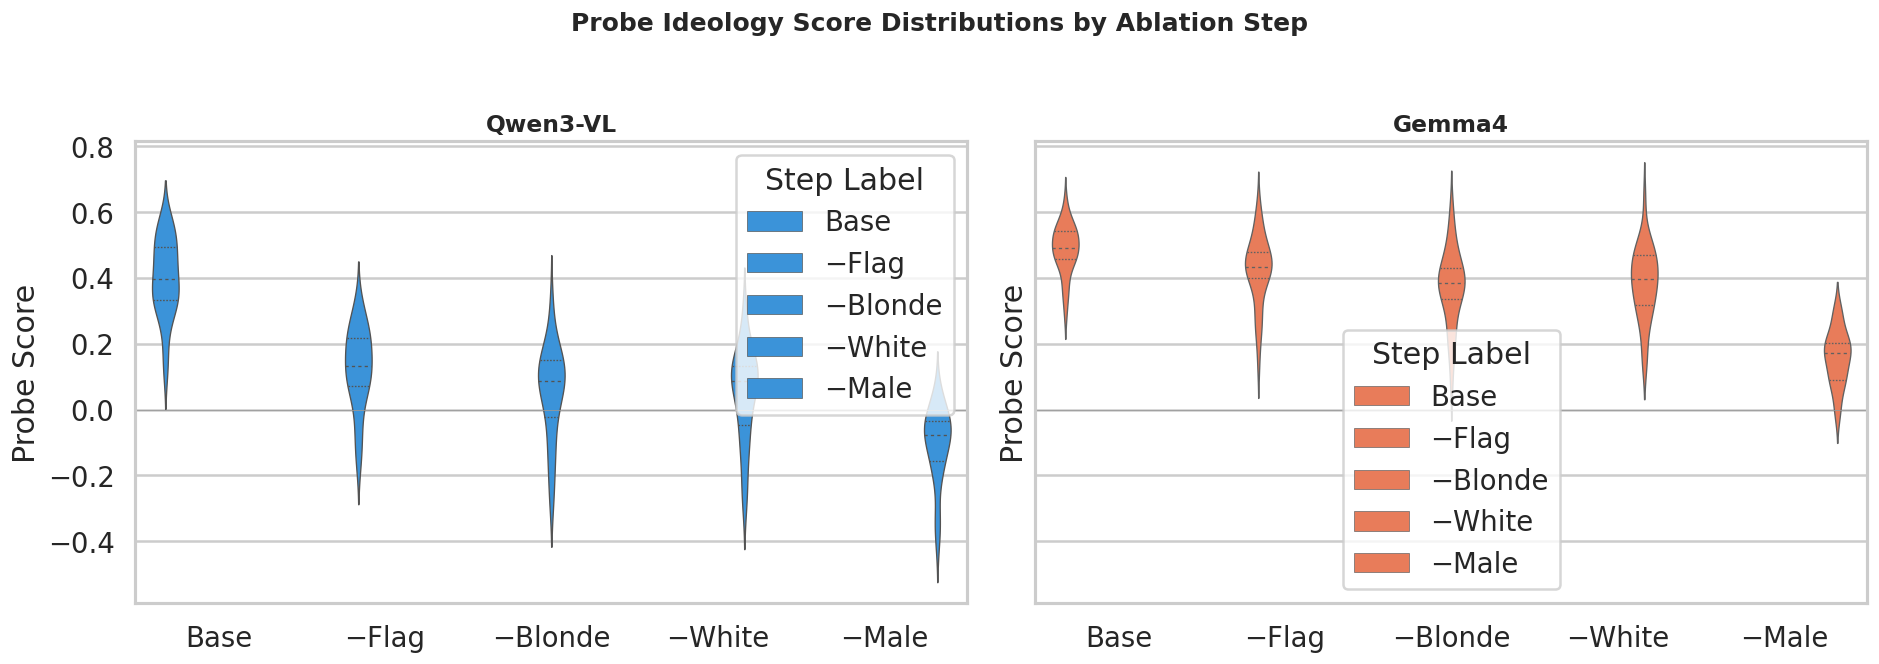

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, df, title, color in [(axes[0], qwen_df, "Qwen3-VL", "#2196F3"), (axes[1], gemma_df, "Gemma4", "#FF7043")]:
    plot_df = df.copy()
    plot_df["Step Label"] = plot_df["step"].map(dict(zip(STEP_ORDER, STEP_SHORT)))
    sns.violinplot(data=plot_df, x="Step Label", y="image_mean", order=STEP_SHORT,
                   palette=[color]*5, inner="quartile", linewidth=0.8, ax=ax, alpha=0.7, hue="Step Label", legend=False)
    ax.set_title(title, fontweight="bold", fontsize=14); ax.set_ylabel("Probe Score"); ax.set_xlabel("")
    ax.axhline(0, color="#999", linewidth=0.5, linestyle="-")
fig.suptitle("Probe Ideology Score Distributions by Ablation Step", fontweight="bold", fontsize=15, y=1.02)
fig.tight_layout(); plt.show()

## Figure 6 — Per-Token Probe Score Heatmap Overlays

Per-token probe scores overlaid onto the actual portrait images (alpha=0.5).
Blue patches = scored more liberal; Red patches = scored more conservative.
Shows 2 example persons × 5 steps for Qwen3-VL.

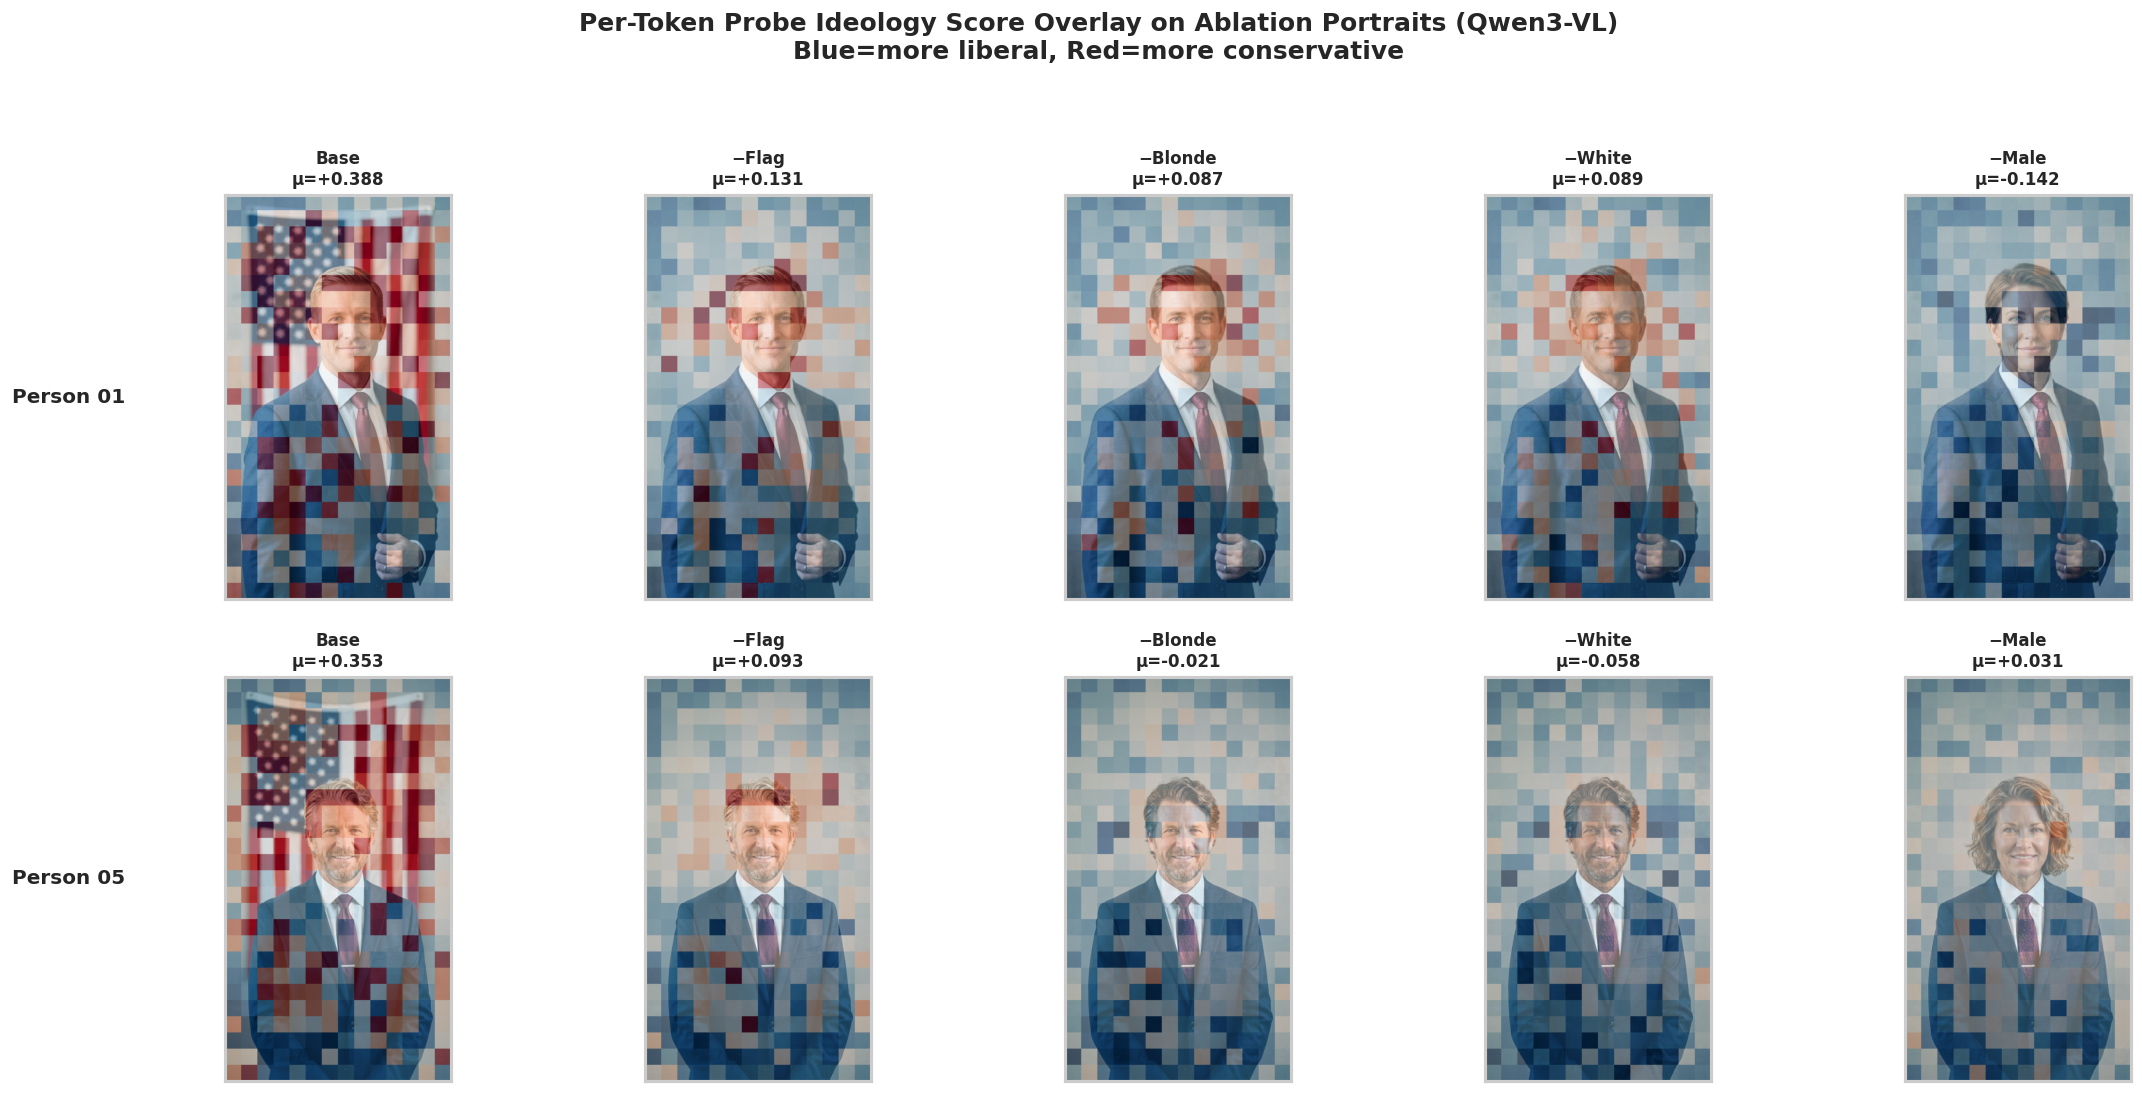

In [10]:
from PIL import Image

def overlay_heatmap_on_image(img_pil, heatmap_2d, alpha=0.45, cmap="RdBu_r", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    h_img, w_img = img.shape[:2]
    hm = heatmap_2d.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)
    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((w_img, h_img), resample=Image.Resampling.NEAREST)
    ) / 255.0
    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)

def load_raw_score_map(pt_path):
    pt = torch.load(pt_path, map_location='cpu', weights_only=False)
    scores = pt['scores'].numpy(); offsets = pt['offsets'].numpy(); grid_hw = pt['grid_hw'].numpy()
    result = {}
    for i, rid in enumerate(pt['record_ids']):
        s = scores[offsets[i]:offsets[i+1]]
        gh, gw = int(grid_hw[i][0]), int(grid_hw[i][1])
        result[rid] = s.reshape(gh, gw) if len(s) == gh*gw else s.reshape(-1, gw)
    return result

qwen_raw = load_raw_score_map("results/qwen3-vl-8b-instruct/prompt_image_token_scores_combined_ideology_headwise_linear.pt")

overlay_persons = ["person_01", "person_05"]
ABLATION_DIR = Path("data/ablation_study")

all_qwen_vals = np.concatenate([v.ravel() for v in qwen_raw.values()])
global_vmin, global_vmax = np.percentile(all_qwen_vals, 2), np.percentile(all_qwen_vals, 98)

n_p = len(overlay_persons)
fig, axes = plt.subplots(n_p, 5, figsize=(5 * 4, n_p * 4.5))
if n_p == 1: axes = np.array([axes])

for row, pid in enumerate(overlay_persons):
    for col, (step, label) in enumerate(zip(STEP_ORDER, STEP_SHORT)):
        ax = axes[row][col]
        img_path = ABLATION_DIR / pid / f"{step}.jpg"
        rid = f"ablation_{pid}_{step}"

        if img_path.exists() and rid in qwen_raw:
            img = Image.open(img_path)
            grid = qwen_raw[rid]
            overlay = overlay_heatmap_on_image(img, grid, alpha=0.45, cmap="RdBu_r",
                                                vmin=global_vmin, vmax=global_vmax)
            ax.imshow(overlay)
            ax.set_xticks([]); ax.set_yticks([])
            mean_val = grid.mean()
            ax.set_title(f"{label}\nμ={mean_val:+.3f}", fontsize=10, fontweight="bold")
        else:
            ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha='center', fontsize=14)
            ax.set_xticks([]); ax.set_yticks([])

    axes[row][0].set_ylabel(pid.replace("_"," ").title(), fontweight="bold", fontsize=12, rotation=0, ha='right', va='center', labelpad=60)

fig.suptitle("Per-Token Probe Ideology Score Overlay on Ablation Portraits (Qwen3-VL)\nBlue=more liberal, Red=more conservative",
             fontweight="bold", fontsize=15, y=1.02)
fig.tight_layout(); plt.show()

## Figure 7 — Δ Heatmap Overlays: Where Does the Probe Change Its Mind?

Spatial difference heatmaps overlaid on the *after* image.
Blue = patches scored more liberal after the edit; Red = more conservative.

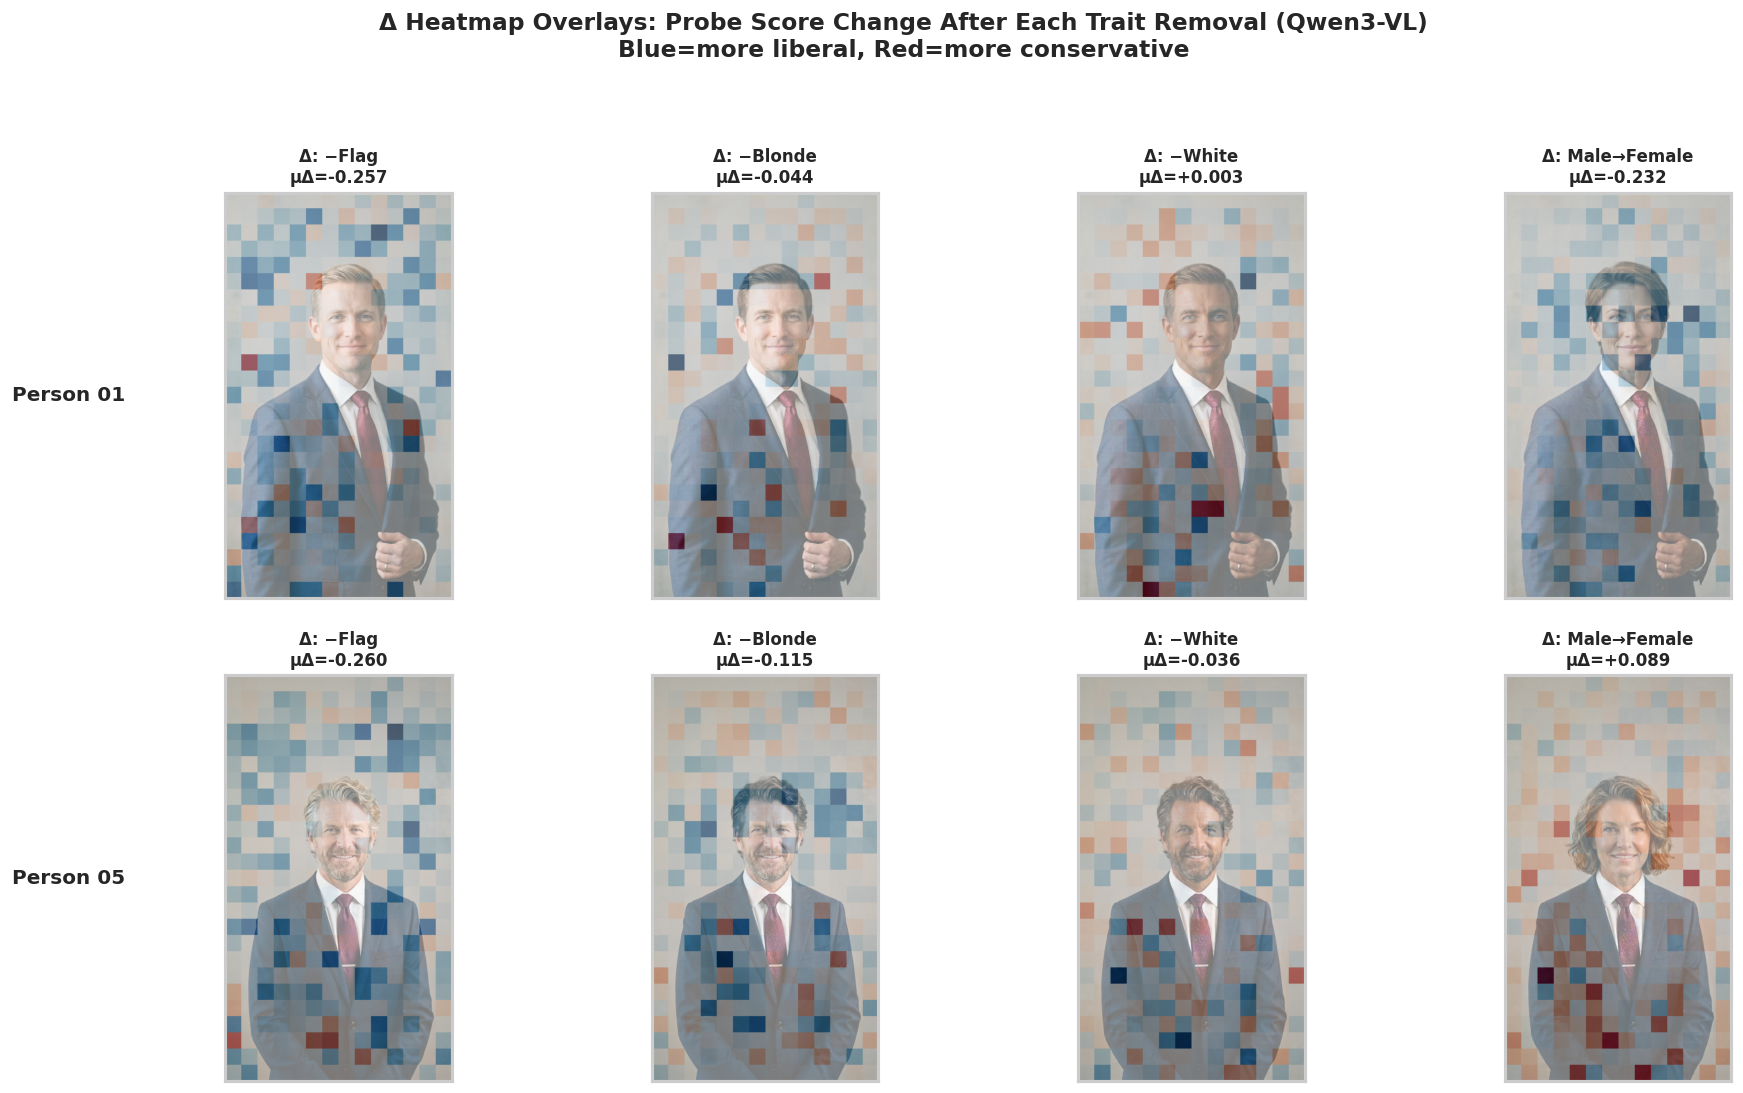

In [11]:
TRAIT_SHORT = ["Δ: −Flag", "Δ: −Blonde", "Δ: −White", "Δ: Male→Female"]
delta_persons = ["person_01", "person_05"]
n_p = len(delta_persons)

fig, axes = plt.subplots(n_p, 4, figsize=(4 * 4.2, n_p * 4.5))
if n_p == 1: axes = np.array([axes])

for row, pid in enumerate(delta_persons):
    for d_idx in range(4):
        ax = axes[row][d_idx]
        before_rid = f"ablation_{pid}_{STEP_ORDER[d_idx]}"
        after_rid = f"ablation_{pid}_{STEP_ORDER[d_idx+1]}"
        after_img_path = ABLATION_DIR / pid / f"{STEP_ORDER[d_idx+1]}.jpg"

        if before_rid in qwen_raw and after_rid in qwen_raw and after_img_path.exists():
            delta = qwen_raw[after_rid] - qwen_raw[before_rid]
            dmax = max(abs(delta.min()), abs(delta.max()), 0.25)
            overlay = overlay_heatmap_on_image(
                Image.open(after_img_path), delta, alpha=0.50, cmap="RdBu_r",
                vmin=-dmax, vmax=dmax)
            ax.imshow(overlay)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f"{TRAIT_SHORT[d_idx]}\nμΔ={delta.mean():+.3f}", fontsize=10, fontweight="bold")
        else:
            ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha='center', fontsize=14)
            ax.set_xticks([]); ax.set_yticks([])

    axes[row][0].set_ylabel(pid.replace("_"," ").title(), fontweight="bold", fontsize=12, rotation=0, ha='right', va='center', labelpad=60)

fig.suptitle("Δ Heatmap Overlays: Probe Score Change After Each Trait Removal (Qwen3-VL)\nBlue=more liberal, Red=more conservative",
             fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

## Interpretation

- **Δ Flag** (Qwen −0.27***, Gemma −0.06***): removing the American flag makes probe scores more liberal, especially for Qwen3-VL. The spatial heatmaps show flag removal changes scores broadly across the entire image.
- **Δ Blonde→Dark** (Qwen −0.07***, Gemma −0.05***): modest but consistent shift toward liberal. Heatmaps localize this change around the head/hair region.
- **Δ White→Non-white** (Qwen −0.009, Gemma +0.01, both n.s.): **zero effect** — in direct contradiction to the observational regression β≈0.2. The regression coefficient was inflated by confounding with party affiliation in real congress data.
- **Δ Male→Female** (Qwen −0.15***, Gemma −0.22***): largest delta in the chain. Consistent direction — female portraits scored much more liberal. Matches the observational β.
- The **Δ heatmaps** reveal that edits affecting the head/face region (hair, gender) produce localized score changes, while the flag removal produces a global shift.